# Post-Phase-3 Verification Results

This notebook visualizes outputs generated by `scripts/run_post_phase3_verification.sh`.

It automatically finds the latest files in `results/test_scan/` for:
- benchmark throughput
- GPU sweep
- CPU sweep

In [13]:
from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt



plt.style.use('seaborn-v0_8-whitegrid')



def find_repo_root(start: Path) -> Path:

    for p in [start, *start.parents]:

        if (p / 'pyproject.toml').exists() and (p / 'results').exists():

            return p

    raise FileNotFoundError('Could not locate repository root from current working directory.')



ROOT = find_repo_root(Path.cwd())

RESULTS_DIR = ROOT / 'results' / 'test_scan'



def pick_latest(prefix: str) -> Path:

    files = sorted(RESULTS_DIR.glob(f'{prefix}_*.csv'))

    if files:

        return files[-1]



    fallback = RESULTS_DIR / f'{prefix}.csv'

    if fallback.exists():

        return fallback



    raise FileNotFoundError(f'Could not find {prefix} CSV in {RESULTS_DIR}')



bench_path = pick_latest('post_phase3_benchmark')

gpu_path = pick_latest('post_phase3_gpu')

cpu_path = pick_latest('post_phase3_cpu')



bench = pd.read_csv(bench_path)

gpu = pd.read_csv(gpu_path)

cpu = pd.read_csv(cpu_path)



print('Repository root:', ROOT)

print('Using files:')

print(f'  benchmark: {bench_path}')

print(f'  gpu sweep: {gpu_path}')

print(f'  cpu sweep: {cpu_path}')



bench.head()

Repository root: /home/alon/Documents/VS_code/Quntum-measurment-model
Using files:
  benchmark: /home/alon/Documents/VS_code/Quntum-measurment-model/results/test_scan/post_phase3_benchmark_20260320_000907.csv
  gpu sweep: /home/alon/Documents/VS_code/Quntum-measurment-model/results/test_scan/post_phase3_gpu_20260320_000907.csv
  cpu sweep: /home/alon/Documents/VS_code/Quntum-measurment-model/results/test_scan/post_phase3_cpu_20260320_000907.csv


,simulator,device,batch_size,n_trajectories,n_steps,throughput_traj_per_sec,std_traj_per_sec
0,l_qubit,cpu,1,128,200,10.879257,0.073193
1,l_qubit,cpu,2,128,200,16.670188,0.202501
2,l_qubit,cpu,4,128,200,18.987239,0.019949
3,l_qubit,cpu,8,128,200,20.921780,0.017562
4,l_qubit,cpu,16,128,200,23.348279,0.144382


In [14]:
merged = gpu.merge(cpu, on=['L', 'gamma'], suffixes=('_gpu', '_cpu'))
if merged.empty:
    raise ValueError('No overlap between GPU and CPU sweep CSV files.')

rel = (merged['n_inf_sim_gpu'] - merged['n_inf_sim_cpu']).abs() / np.maximum(merged['n_inf_sim_cpu'].abs(), 1e-12)
summary = pd.DataFrame({
    'metric': ['rows', 'max_rel_diff', 'mean_rel_diff', 'threshold_1pct_pass'],
    'value': [len(merged), rel.max(), rel.mean(), bool((rel <= 0.01).all())],
})

summary

,metric,value
0,rows,6
1,max_rel_diff,0.0
2,mean_rel_diff,0.0
3,threshold_1pct_pass,True


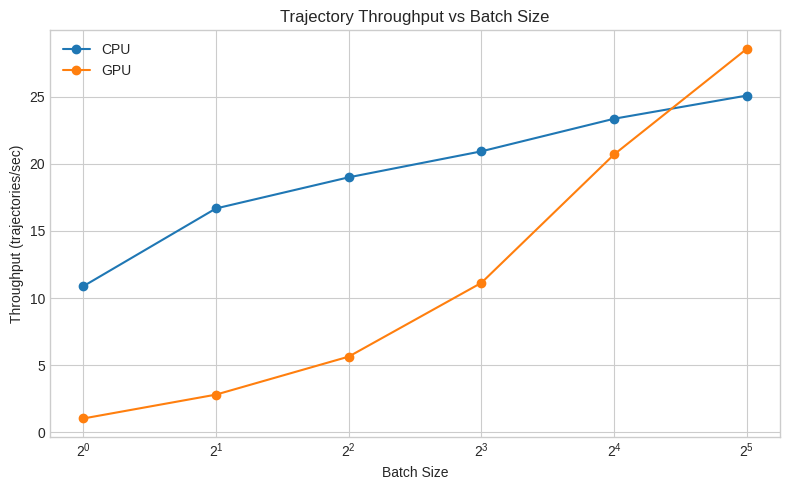

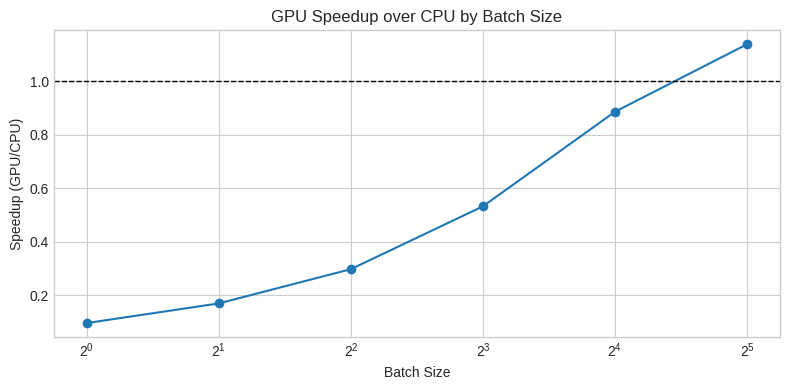

,gpu_over_cpu_speedup
batch_size,
1,0.095367
2,0.168830
4,0.297120
8,0.532167
16,0.886136
32,1.138740


In [15]:
# Throughput by batch size and device
fig, ax = plt.subplots(figsize=(8, 5))
for device, grp in bench.groupby('device'):
    grp = grp.sort_values('batch_size')
    ax.plot(grp['batch_size'], grp['throughput_traj_per_sec'], marker='o', label=device.upper())

ax.set_title('Trajectory Throughput vs Batch Size')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Throughput (trajectories/sec)')
ax.set_xscale('log', base=2)
ax.legend()
plt.tight_layout()
plt.show()

cpu_t = bench[bench['device'] == 'cpu'][['batch_size', 'throughput_traj_per_sec']].set_index('batch_size')
gpu_t = bench[bench['device'] == 'gpu'][['batch_size', 'throughput_traj_per_sec']].set_index('batch_size')
if not cpu_t.empty and not gpu_t.empty:
    speedup = (gpu_t['throughput_traj_per_sec'] / cpu_t['throughput_traj_per_sec']).dropna()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(speedup.index, speedup.values, marker='o')
    ax.axhline(1.0, linestyle='--', color='black', linewidth=1)
    ax.set_title('GPU Speedup over CPU by Batch Size')
    ax.set_xlabel('Batch Size')
    ax.set_ylabel('Speedup (GPU/CPU)')
    ax.set_xscale('log', base=2)
    plt.tight_layout()
    plt.show()

    display(speedup.rename('gpu_over_cpu_speedup').to_frame())

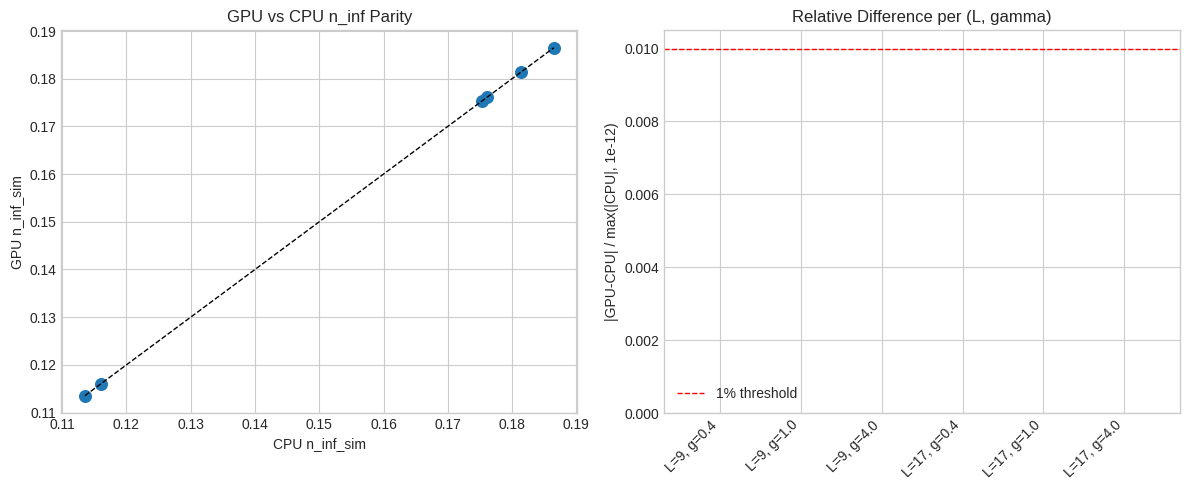

In [16]:
# Pointwise agreement between GPU and CPU sweeps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# n_inf parity plot
axes[0].scatter(merged['n_inf_sim_cpu'], merged['n_inf_sim_gpu'], s=70)
mn = min(merged['n_inf_sim_cpu'].min(), merged['n_inf_sim_gpu'].min())
mx = max(merged['n_inf_sim_cpu'].max(), merged['n_inf_sim_gpu'].max())
axes[0].plot([mn, mx], [mn, mx], '--', color='black', linewidth=1)
axes[0].set_title('GPU vs CPU n_inf Parity')
axes[0].set_xlabel('CPU n_inf_sim')
axes[0].set_ylabel('GPU n_inf_sim')

# Relative difference by point
point_labels = merged.apply(lambda r: f"L={int(r['L'])}, g={r['gamma']}", axis=1)
axes[1].bar(range(len(rel)), rel.values)
axes[1].axhline(0.01, linestyle='--', color='red', linewidth=1, label='1% threshold')
axes[1].set_title('Relative Difference per (L, gamma)')
axes[1].set_ylabel('|GPU-CPU| / max(|CPU|, 1e-12)')
axes[1].set_xticks(range(len(rel)))
axes[1].set_xticklabels(point_labels, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

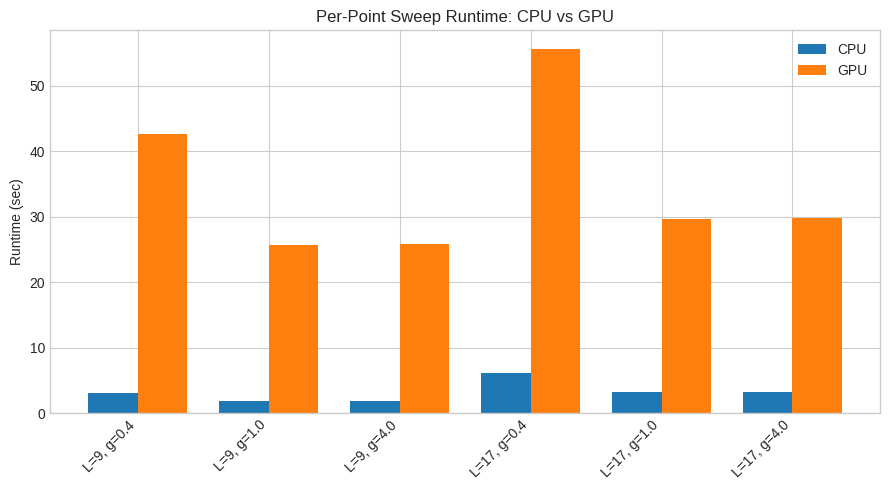

,L,gamma,runtime_sec_gpu,runtime_sec_cpu,ratio_gpu_over_cpu
0,9,0.4,42.693784,3.119566,13.685807
1,9,1.0,25.719007,1.880795,13.674537
2,9,4.0,25.791796,1.897953,13.589268
3,17,0.4,55.719869,6.126985,9.094174
4,17,1.0,29.642251,3.261801,9.087693
5,17,4.0,29.780484,3.296889,9.032904


In [17]:
# Runtime comparison for scan points
runtime_cmp = merged[['L', 'gamma', 'runtime_sec_gpu', 'runtime_sec_cpu']].copy()
runtime_cmp['ratio_gpu_over_cpu'] = runtime_cmp['runtime_sec_gpu'] / np.maximum(runtime_cmp['runtime_sec_cpu'], 1e-12)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(runtime_cmp))
w = 0.38
ax.bar(x - w/2, runtime_cmp['runtime_sec_cpu'], width=w, label='CPU')
ax.bar(x + w/2, runtime_cmp['runtime_sec_gpu'], width=w, label='GPU')
ax.set_title('Per-Point Sweep Runtime: CPU vs GPU')
ax.set_ylabel('Runtime (sec)')
ax.set_xticks(x)
ax.set_xticklabels(runtime_cmp.apply(lambda r: f"L={int(r['L'])}, g={r['gamma']}", axis=1), rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

runtime_cmp

In [19]:
from IPython.display import Markdown, display

max_rel = float(rel.max())
mean_rel = float(rel.mean())
pass_1pct = bool((rel <= 0.01).all())

cpu_total_runtime = float(merged['runtime_sec_cpu'].sum())
gpu_total_runtime = float(merged['runtime_sec_gpu'].sum())
scan_speed_ratio = gpu_total_runtime / max(cpu_total_runtime, 1e-12)

if 'speedup' in globals() and len(speedup) > 0:
    best_batch = int(speedup.idxmax())
    best_speedup = float(speedup.max())
else:
    best_batch = None
    best_speedup = float('nan')

status = 'PASS' if pass_1pct else 'FAIL'

lines = [
    '## Post-Phase-3 Report Card',
    '',
    f'- Correctness threshold (<=1%): **{status}**',
    f'- Overlap points compared: **{len(merged)}**',
    f'- Max relative difference: **{max_rel:.3e}**',
    f'- Mean relative difference: **{mean_rel:.3e}**',
    f'- Small-sweep runtime ratio (GPU/CPU): **{scan_speed_ratio:.2f}x**',
]

if best_batch is not None:
    lines.append(f'- Best benchmark speedup: **{best_speedup:.2f}x** at batch size **{best_batch}**')

report_md = '\n'.join(lines)
display(Markdown(report_md))
print(report_md)

## Post-Phase-3 Report Card

- Correctness threshold (<=1%): **PASS**
- Overlap points compared: **6**
- Max relative difference: **3.367e-15**
- Mean relative difference: **1.021e-15**
- Small-sweep runtime ratio (GPU/CPU): **10.69x**
- Best benchmark speedup: **1.14x** at batch size **32**

## Post-Phase-3 Report Card

- Correctness threshold (<=1%): **PASS**
- Overlap points compared: **6**
- Max relative difference: **3.367e-15**
- Mean relative difference: **1.021e-15**
- Small-sweep runtime ratio (GPU/CPU): **10.69x**
- Best benchmark speedup: **1.14x** at batch size **32**


## Notes

- This notebook reports both correctness (GPU vs CPU agreement) and performance (throughput/runtime).
- If GPU is slower at small workloads, increase batch size and system size for more representative GPU scaling.
- You can rerun this notebook after each verification run; it will pick the latest timestamped CSV files automatically.